#1.Імпорт всіх необхідних бібліотек

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import importlib
import src.evaluation
importlib.reload(src.evaluation)
from src.evaluation import evaluate_model, plot_cm
import src.preprocessing
from src.preprocessing import preprocess_news_data

In [ ]:
pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', '{:.4f}'.format)
pd.set_option("display.max_colwidth",None)

warnings.filterwarnings('ignore')

#2. Завантаження даних

In [ ]:
train_df = pd.read_csv("data/train.csv.zip")
valid_df = pd.read_csv("data/valid.csv.zip")
test_df = pd.read_csv("data/test.csv.zip")

X_train = train_df["text"]
y_train = train_df["category"]

X_valid = valid_df["text"]
y_valid = valid_df["category"]

X_test = test_df["text"]
y_test = test_df["category"]

#3. Підготовка target

In [ ]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)
y_valid = encoder.transform(y_valid)
y_test = encoder.transform(y_test)

#4. Векторизація тексту (TF-IDF)

In [ ]:
start = time.time()

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
tfidf.get_feature_names_out()[:20]

array(['000', '000 people', '10', '10 000', '10 best', '10 million',
       '10 percent', '10 reasons', '10 things', '10 tips', '10 ways',
       '10 year', '10 years', '100', '100 000', '100 days', '100 million',
       '100 percent', '100 years', '101'], dtype=object)

In [ ]:
print("Train:", X_train_tfidf.shape)
print("Validation:", X_valid_tfidf.shape)
print("Test:", X_test_tfidf.shape)

Train: (146335, 10000)
Validation: (31358, 10000)
Test: (31358, 10000)


#5. Зменшення розмірності SVD

In [ ]:
svd = TruncatedSVD(n_components=200,random_state=42)

In [ ]:
X_train_svd = svd.fit_transform(X_train_tfidf)

X_valid_svd = svd.transform(X_valid_tfidf)

X_test_svd = svd.transform(X_test_tfidf)


In [ ]:
X_train_svd.shape

(146335, 200)

#6. Побудова XGBoost-моделі з оптимізатором гіперпараметрів RandomizedSearchCV

In [ ]:
xgb = XGBClassifier(
    random_state=42,
    tree_method="hist",
    n_jobs=1,
    objective="multi:softmax",
    num_class=len(encoder.classes_),
    eval_metric="mlogloss"
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3,5],
    "learning_rate": [0.05,0.1]
}

search = RandomizedSearchCV(
    xgb,
    param_grid,
    n_iter=4,
    scoring="f1_macro",
    cv=2,
    n_jobs=-1,
    verbose=2
)

In [ ]:
search.fit(X_train_svd, y_train)

training_time = time.time() - start

formatted_time = time.strftime(
    "%H:%M:%S",
    time.gmtime(training_time)
)

print(f"Час навчання: {formatted_time}")

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Час навчання: 01:21:12


Найкращі параметри:

In [ ]:
search.best_params_

{'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}

# 7. Оцінка XGBoost-моделі з оптимізатором

##7.1 Розрахунок передбачень

In [ ]:
best_xgb = search.best_estimator_

train_accuracy, train_macro_f1, train_weighted_f1, y_train_pred = evaluate_model(
    best_xgb,
    X_train_svd,
    y_train
)
valid_accuracy, valid_macro_f1, valid_weighted_f1,  y_valid_pred = evaluate_model(
    best_xgb,
    X_valid_svd,
    y_valid
)

##7.2 Порівняння метрик

Основною метрикою оцінювання моделей обрано Macro F1-score, оскільки задача є багатокласовою класифікацією з незбалансованим розподілом класів. Ця метрика дозволяє оцінити якість моделі для всіх категорій незалежно від їх розміру.  

В якості допоміжних метрик обрано:
* Accuracy - показує загальну частку правильних прогнозів.
* Weighted F1-score - вона враховує дисбаланс класів.

Проведемо порівняння метрик:

In [ ]:
results = pd.DataFrame({
    "Dataset": ["Train", "Validation"],
    "Accuracy": [train_accuracy, valid_accuracy],
    "Macro F1": [train_macro_f1, valid_macro_f1],
    "Weighted F1": [train_weighted_f1, valid_weighted_f1]
})
results

,Dataset,Accuracy,Macro F1,Weighted F1
0,Train,0.5775,0.4966,0.5582
1,Validation,0.4726,0.2960,0.4322


***Висновок:***
* Побудована модель XGBoost із TruncatedSVD не перевершила базової моделі Logistic Regression. Незважаючи на підбір гіперпараметрів, модель показала нижчий Macro F1 на валідаційній вибірці.

##7.3 Детальний classification report

Побудуємо детальний звіт для тестовго та валідаційного наборів даних:

In [ ]:
print(classification_report(y_train, y_train_pred, target_names=encoder.classes_))

                precision    recall  f1-score   support

          ARTS       0.61      0.28      0.38      1056
ARTS & CULTURE       0.80      0.28      0.42       937
  BLACK VOICES       0.60      0.30      0.40      3206
      BUSINESS       0.52      0.36      0.43      4192
       COLLEGE       0.63      0.54      0.58       801
        COMEDY       0.65      0.31      0.42      3773
         CRIME       0.52      0.60      0.56      2490
CULTURE & ARTS       0.79      0.40      0.53       751
       DIVORCE       0.86      0.69      0.76      2396
     EDUCATION       0.70      0.58      0.63       710
 ENTERTAINMENT       0.46      0.67      0.55     12150
   ENVIRONMENT       0.87      0.31      0.46      1010
         FIFTY       0.93      0.20      0.33       981
  FOOD & DRINK       0.63      0.68      0.66      4438
     GOOD NEWS       0.84      0.34      0.48       979
         GREEN       0.57      0.36      0.44      1832
HEALTHY LIVING       0.56      0.17      0.27  

In [ ]:
print(classification_report(y_valid, y_valid_pred, target_names=encoder.classes_))

                precision    recall  f1-score   support

          ARTS       0.23      0.10      0.14       227
ARTS & CULTURE       0.37      0.05      0.10       201
  BLACK VOICES       0.43      0.20      0.27       687
      BUSINESS       0.35      0.24      0.29       899
       COLLEGE       0.41      0.29      0.34       171
        COMEDY       0.50      0.21      0.29       809
         CRIME       0.38      0.45      0.41       534
CULTURE & ARTS       0.45      0.15      0.22       161
       DIVORCE       0.76      0.55      0.64       514
     EDUCATION       0.31      0.19      0.24       152
 ENTERTAINMENT       0.41      0.63      0.49      2604
   ENVIRONMENT       0.36      0.07      0.12       216
         FIFTY       0.15      0.01      0.02       210
  FOOD & DRINK       0.50      0.54      0.52       951
     GOOD NEWS       0.15      0.03      0.05       209
         GREEN       0.29      0.18      0.22       393
HEALTHY LIVING       0.30      0.08      0.13  

***Висновки:***
* XGBoost показав задовільні результати для найбільш представлених категорій (POLITICS, STYLE & BEAUTY, WEDDINGS, FOOD & DRINK), однак значно гірше класифікував малочисельні категорії. Це призвело до невисокого значення Macro F1-score, що свідчить про нерівномірну якість класифікації між класами.

# 8. Аналіз результатів baseline-моделі

##8.1 Матриця помилок

Побудуємо нормалізовану матрицю помилок навчального та валідаційного наборів даних:

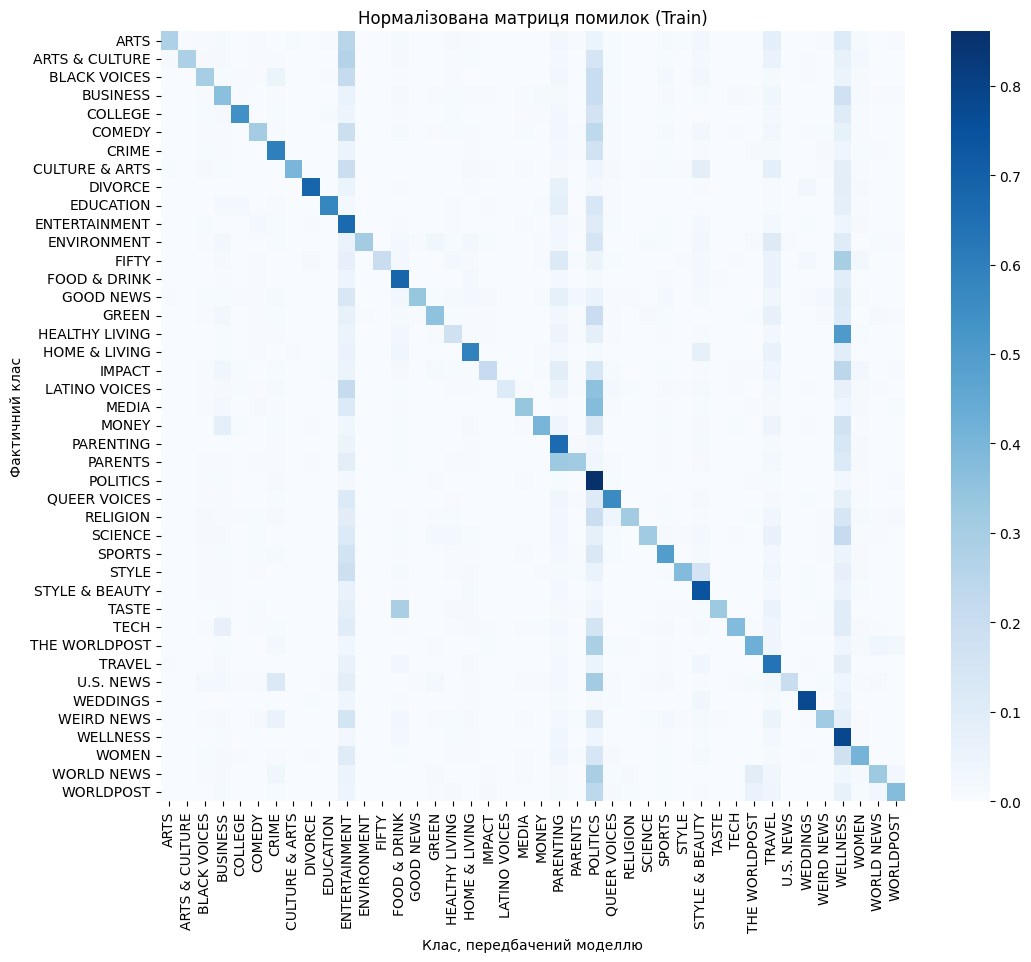

In [ ]:
plot_cm(
    pd.Series(
        encoder.inverse_transform(y_train)
    ),
    pd.Series(
        encoder.inverse_transform(y_train_pred)
    ),
    "Train"
)

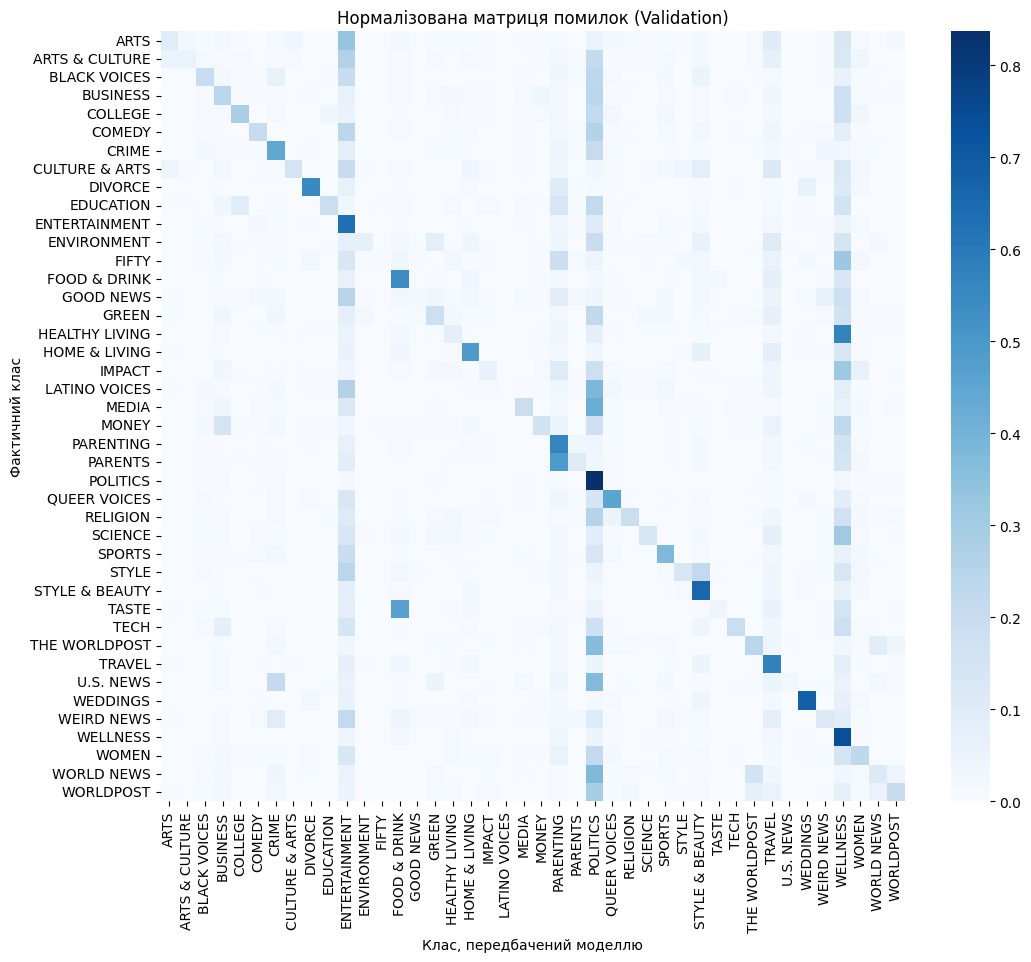

In [ ]:
plot_cm(
    pd.Series(
        encoder.inverse_transform(y_valid)
    ),
    pd.Series(
        encoder.inverse_transform(y_valid_pred)
    ),
    "Validation"
)

***Висновки:***
* Загалом нормалізована матриця помилок для валідаційного набору даних має подібну картину, як і нормалізована матриця помилок для трунвального набору даних.
* Нормалізована матриця помилок для валідаційної вибірки демонструє, що модель добре класифікує найбільш представлені категорії, зокрема POLITICS, STYLE & BEAUTY, WEDDINGS та TRAVEL. Водночас спостерігається тенденція до помилкового віднесення менш представлених категорій до популярних класів, таких як POLITICS, ENTERTAINMENT та WELLNESS.

##8.2 Аналіз помилок моделі

In [ ]:
errors = pd.DataFrame({
    "text": X_valid.reset_index(drop=True),
    "true_category": encoder.inverse_transform(y_valid),
    "predicted_category": encoder.inverse_transform(y_valid_pred)
})

errors = errors[
    errors["true_category"] != errors["predicted_category"]
]

errors.sample(10, random_state=42)

,text,true_category,predicted_category
25261,"Oh Lola: From Our Network From WhyDid? ""Lolita"" is a term that is often thrown around without much thought. It's used in songs, slang, and even runway",STYLE & BEAUTY,SCIENCE
1996,How To Stop Feeling Overwhelmed (For Good) Being overwhelmed is not a fact -- it's a state of consciousness that limits your freedom and happiness. It requires a shift in perspective. Bring yourself back to the present moment. Remember that you have a choice about the way you want to feel.,HEALTHY LIVING,WELLNESS
20197,5 Reasons The 2016 Election Feels So Personal It's not just the candidates.,HEALTHY LIVING,POLITICS
12271,"'In the Next Room or the Vibrator Play,' Long Beach Playhouse Studio Theatre Calling it The Vibrator Play teases you into thinking it's only about sex toys. It's not. Calling it In The Next Room better describes the story's more serious plot line.",ARTS,ENTERTAINMENT
8189,Why Liberals & Conservatives Aren't As Different As You Think,SCIENCE,WELLNESS
23043,"The Best Darn Conference of the Year Where Ideas Come Alive: TED Active Quotes from TEDActive 2012 Attendees ""There is more passion per capita in Palm Springs the week of TED than anywhere else",TECH,STYLE & BEAUTY
10196,South Carolina Judge Declares Mistrial In Walter Scott Shooting The jury deliberated over four days.,BLACK VOICES,POLITICS
14253,The Case For Queer Superheroes In Hollywood There’s one character you almost certainly won’t see this year.,QUEER VOICES,ENTERTAINMENT
27392,"Black Lives Matter Protesters Call For Justice At U.S. Mayors Conference Chicago Mayor Rahm Emanuel, Flint Mayor Karen Weaver and Baltimore’s Stephanie Rawlings-Blake were in attendance.",POLITICS,BLACK VOICES
14477,"Pinterest User You Should Follow: Morgan Moore We're sure you've all heard about Pinterest by now, and are aware of its highly addictive qualities. It's a great social",FOOD & DRINK,WELLNESS


In [ ]:
print(f"Кількість помилок: {len(errors)}")
print(f"Частка помилок: {len(errors) / len(y_valid):.2%}")

Кількість помилок: 16538
Частка помилок: 52.74%


In [ ]:
errors_pairs = (
    errors
    .groupby(["true_category", "predicted_category"])
    .size()
    .sort_values(ascending=False)
)

errors_pairs.head(15)

,,0
true_category,predicted_category,
HEALTHY LIVING,WELLNESS,571
PARENTS,PARENTING,287
ENTERTAINMENT,POLITICS,272
BUSINESS,POLITICS,217
PARENTING,WELLNESS,209
COMEDY,POLITICS,209
THE WORLDPOST,POLITICS,199
COMEDY,ENTERTAINMENT,191
WORLD NEWS,POLITICS,187


***Висновки:***

* Аналіз помилок моделі показує, що частина неправильних прогнозів виникає між тематично близькими категоріями.
* Модель добре розпізнає великі категорії, але схильна відносити до них схожі за тематикою новини.